In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from rapidfuzz import process
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.callbacks import EarlyStopping

In [37]:
df = pd.read_csv('future_jobs_dataset.csv')

df.head()

,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,"Linear Algebra, Quantum Algorithms",No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,"Climate Data Analysis, Energy Modeling",Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,"Linear Algebra, Qiskit",No,Medium,2025-12-31
3,4,Sustainability Analyst,Green Tech,Singapore,113822,"Climate Data Analysis, Energy Modeling",No,Large,2025-05-29
4,5,Smart Contract Engineer,Blockchain,London,92575,"Rust, Solidity",Yes,Small,2025-03-30


In [38]:
df.columns

Index(['job_id', 'job_title', 'industry', 'location', 'salary_usd',
       'skills_required', 'remote_option', 'company_size', 'posting_date'],
      dtype='object')

In [39]:
df['posting_date'] = pd.to_datetime(df['posting_date'])

In [40]:
df['skills_required'] = df['skills_required'].str.split(',')

In [41]:
df = df.explode('skills_required')

In [42]:
df['skills_required'] = df['skills_required'].str.strip().str.lower()

In [43]:
df


,job_id,job_title,industry,location,salary_usd,skills_required,remote_option,company_size,posting_date
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,linear algebra,No,Large,2025-07-22
0,1,Quantum Researcher,Quantum Computing,Singapore,175780,quantum algorithms,No,Large,2025-07-22
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,climate data analysis,Yes,Large,2025-09-26
1,2,Renewable Energy Engineer,Green Tech,Singapore,137481,energy modeling,Yes,Large,2025-09-26
2,3,Quantum Researcher,Quantum Computing,Tokyo,182081,linear algebra,No,Medium,2025-12-31
...,...,...,...,...,...,...,...,...,...
9997,9998,Quantum Software Developer,Quantum Computing,Berlin,200382,qiskit,No,Small,2025-02-23
9998,9999,Renewable Energy Engineer,Green Tech,New York,214484,energy modeling,No,Small,2025-03-08
9998,9999,Renewable Energy Engineer,Green Tech,New York,214484,climate data analysis,No,Small,2025-03-08
9999,10000,AI Engineer,AI,Singapore,117307,tensorflow,Yes,Large,2025-08-12


In [45]:
df['month'] = df['posting_date'].dt.to_period('M')

skill_trend = df.groupby(['month','skills_required']).size().reset_index(name='count')

In [46]:
pivot = skill_trend.pivot(
    index='month',
    columns='skills_required',
    values='count'
).fillna(0)

In [62]:
keyword_map = {

    "data": "climate data analysis",
    "analysis": "climate data analysis",
    "analytics": "climate data analysis",
    "data science": "climate data analysis",

    "ai": "tensorflow",
    "machine learning": "tensorflow",
    "deep learning": "pytorch",
    "neural network": "tensorflow",
    "computer vision": "pytorch",

    "quantum": "qiskit",
    "quantum computing": "qiskit",
    "quantum algorithm": "quantum algorithms",

    "web3": "ethereum",
    "blockchain": "ethereum",
    "crypto": "ethereum",
    "cryptocurrency": "ethereum",
    "smart contract": "solidity",

    "html": "solidity",
    "css": "solidity",
    "javascript": "solidity",
    "typescript": "ethereum",
    "react": "ethereum",
    "nextjs": "solidity",
    "next.js": "ethereum",
    "vue": "ethereum",
    "angular": "solidity",
    "svelte": "ethereum",
    "tailwind": "solidity",
    "bootstrap": "ethereum",

    "node": "energy modeling",
    "nodejs": "energy modeling",
    "node.js": "ethereum",
    "express": "ethereum",
    "nestjs": "energy modeling",
    "django": "python",
    "flask": "python",
    "spring": "rust",
    "laravel": "rust",
    "php": "rust",

    "web developer": "ethereum",
    "web development": "ethereum",
    "frontend": "ethereum",
    "backend": "rust",
    "fullstack": "ethereum",

    "solidity": "solidity",
    "ethereum": "ethereum",
    "dapp": "ethereum",
    "defi": "ethereum",
    "nft": "ethereum"
}

In [47]:
pivot.columns.tolist()

['climate data analysis',
 'energy modeling',
 'ethereum',
 'linear algebra',
 'python',
 'pytorch',
 'qiskit',
 'quantum algorithms',
 'rust',
 'solidity',
 'tensorflow']

In [16]:
def find_skill(query):

    query = query.lower()

    # keyword mapping
    for key in keyword_map:
        if key in query:
            return keyword_map[key]

    # fallback ke fuzzy search
    skills = pivot.columns.tolist()

    best_match = process.extractOne(query, skills)

    return best_match[0]

Skill ditemukan: climate data analysis


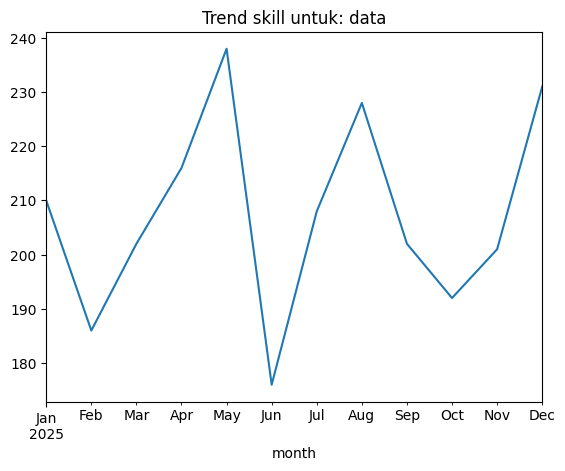

In [61]:
query = "data"

skill = find_skill(query)

print("Skill ditemukan:", skill)

pivot[skill].plot()

plt.title(f"Trend skill untuk: {query}")

plt.show()

In [65]:
def get_skill_trend(query):

    skill = find_skill(query)

    return pivot[skill]

In [ ]:

data = pivot.values

X = data[:-1]
y = data[1:]

print(X.shape, y.shape)

(11, 11) (11, 11)


In [ ]:


model = Sequential([
    Dense(64, activation='relu', input_shape=(pivot.shape[1],)),
    Dense(pivot.shape[1])
])

model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:

scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(pivot.values)

X = data_scaled[:-1]
y = data_scaled[1:]

In [ ]:


early_stop = EarlyStopping(
    monitor='loss',
    patience=20,
    restore_best_weights=True
)


In [73]:
history = model.fit(
    X,
    y,
    epochs=500,
    batch_size=1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 235.1537 
Epoch 2/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 291.0800
Epoch 3/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 286.7413 
Epoch 4/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 304.2403 
Epoch 5/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 284.5532 
Epoch 6/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 296.2648 
Epoch 7/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 246.6542
Epoch 8/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 272.7853 
Epoch 9/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 269.6456 
Epoch 10/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 261.5399 
Epoch 11/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 321.7844 
Epoch 12/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 258.5015 
Epoch 13/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 246.7477 
Epoch 14/500
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 269.3979 
Epoch 15/500
11/11 ━━━━━━━━━━━━

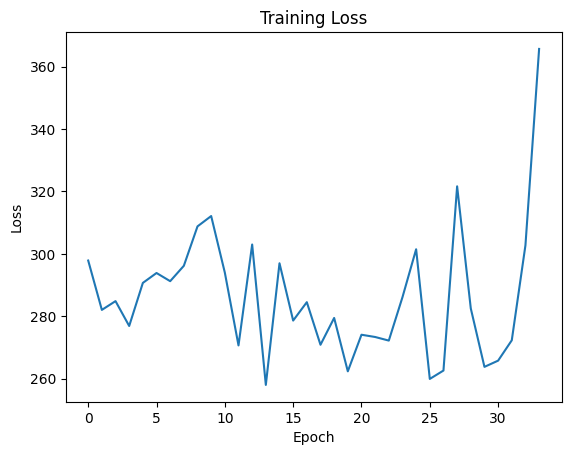

In [74]:
plt.plot(history.history['loss'])
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [76]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(pivot.values)

last_month_scaled = data_scaled[-1].reshape(1,-1)

prediction_scaled = model.predict(last_month_scaled)

prediction = scaler.inverse_transform(prediction_scaled)

prediction = prediction.flatten()

predicted = pd.Series(prediction, index=pivot.columns)

print(predicted.sort_values(ascending=False))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
skills_required
climate data analysis    280.328033
energy modeling          276.862885
qiskit                   171.462021
linear algebra           168.147171
ethereum                 166.541260
pytorch                  165.528793
quantum algorithms       165.070358
solidity                 164.415848
python                   161.316528
rust                     156.301117
tensorflow               152.316223
dtype: float32


In [77]:
pivot.to_csv("skill_trend_dataset.csv")

In [78]:
import joblib

joblib.dump(scaler, "scaler.save")

['scaler.save']

In [79]:
model.save("skill_trend_model.keras")